# Sentiment Analysis  on Tweets
#
# The steps:
# 
# **Task 1 – Descriptive Analysis:**
#  - Loading the tweet dataset
#  - Exploring the distribution of sentiment labels
#  - Analyzing tweet lengths, common words, and hashtags
#
# **Task 2 – Sentiment Classification:**
#  - Preprocessing (cleaning, tokenization, and lemmatization)
#  - Vectorizing text using TF-IDF and computing Delta TF-IDF
#  - Training three models: Naïve Bayes, Logistic Regression, and an RNN (LSTM)
#  - Evaluating models using accuracy, precision, recall, and F1-score
#  - Using the best model (RNN) on the test dataset

In [ ]:
# Step 1: Import required libraries 
import pandas as pd
import numpy as np
import re, string
from collections import Counter



In [27]:
# Step 2: Load the Datasets with the Corrected Approach

# Load training data
train_file = 'train_tweets.txt'
df_train = pd.read_csv(train_file, header=None, delimiter='\t', quoting=3, on_bad_lines='skip', engine='python')
df_train = df_train.drop(columns=[3])  # Drop the extra column if it exists
df_train.rename(columns={0: "IDF", 1: "Polarity", 2: "Tweet"}, inplace=True)

# Load test data similarly
test_file = 'test_tweets.txt'
df_test = pd.read_csv(test_file, header=None, delimiter='\t', quoting=3, on_bad_lines='skip', engine='python')

df_test.rename(columns={0: "IDF", 1: "Polarity", 2: "Tweet"}, inplace=True)

print("Train sample:")
print(df_train.head())
print("\nTest sample:")
print(df_test.head())


Train sample:
                  IDF  Polarity  \
0  619971047195045888        -1   
1  620067692066828288        -1   
2  620099074679701509        -1   
3  620149443191533568        -1   
4  620152459676282880        -1   

                                               Tweet  
0  "If these runway renovations at the airport pr...  
1  Bad Blood may have the absolute worst lyricism...  
2  My parents are going to the Zac Brown Band con...  
3  The growth of gerontocracy: George Osborne's a...  
4  The hidden Budget tax rises George Osborne did...  

Test sample:
                  IDF  Polarity  \
0  802198774114385024        -1   
1  802198916489874944        -1   
2  802198916594887936        -1   
3  802199759872109952        -1   
4  802203076522364032        -1   

                                               Tweet  
0  Soros brainwashes & enslaves U #blacklivesmatt...  
1  Iggy from the"Revolution Club" mad that Trump ...  
2  #BlackLivesMatter #potus #HillaryClinton You c...  


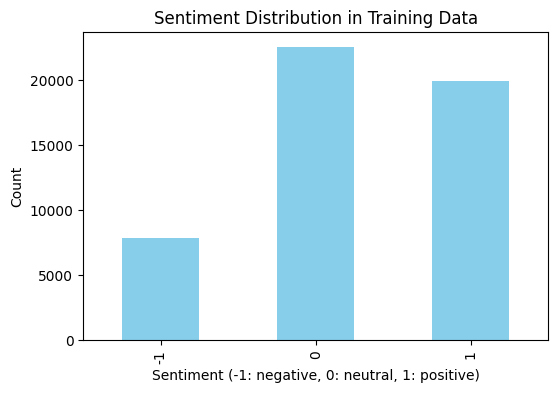

In [28]:
# Step 3: Descriptive Analysis – Sentiment Distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df_train['Polarity'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title("Sentiment Distribution in Training Data")
plt.xlabel("Sentiment (-1: negative, 0: neutral, 1: positive)")
plt.ylabel("Count")
plt.show()


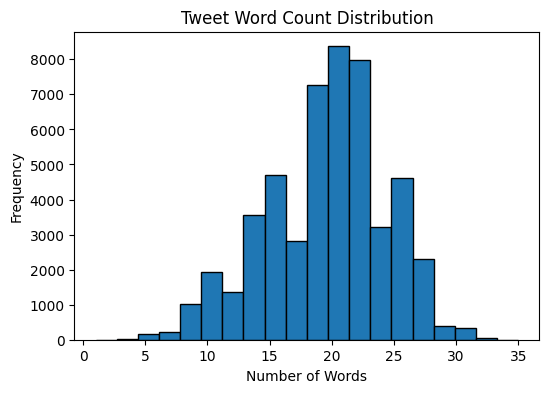

In [29]:
# Step 4: Compute and plot the distribution of tweet word counts

# Calculate word count for each tweet
df_train['word_count'] = df_train['Tweet'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6, 4))
plt.hist(df_train['word_count'], bins=20, edgecolor='black')
plt.title("Tweet Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


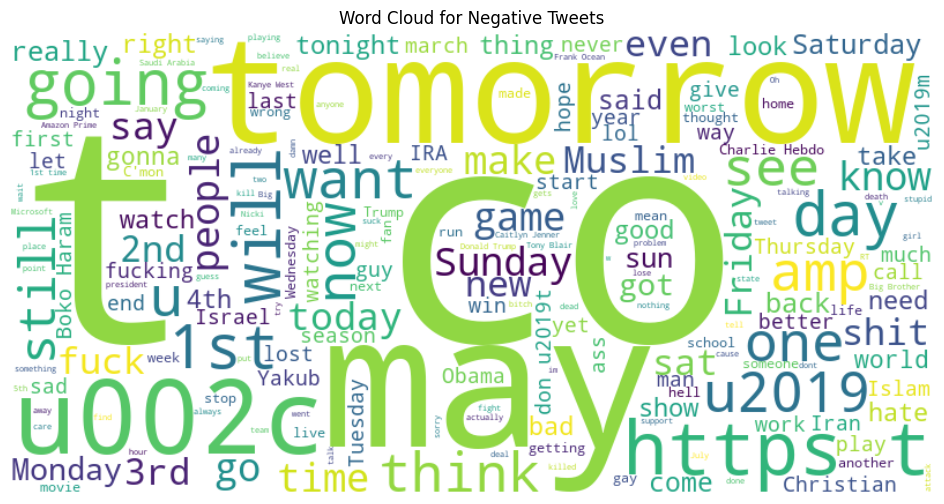

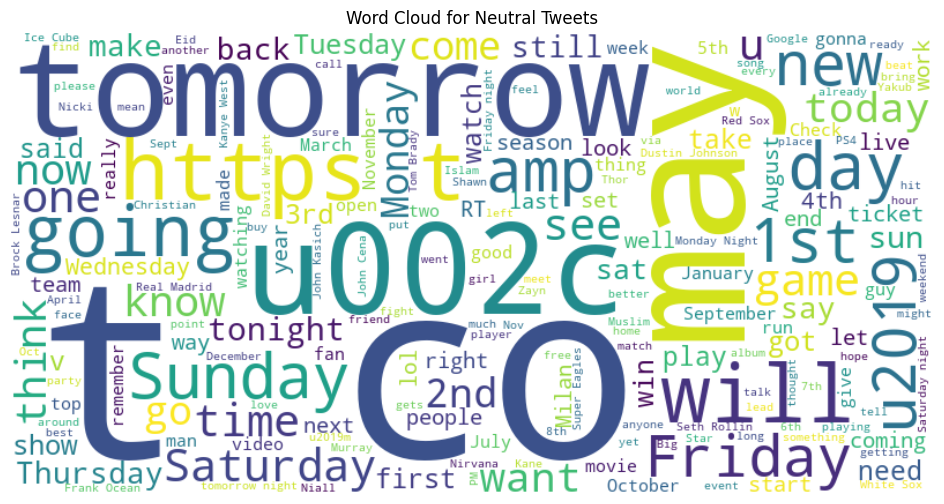

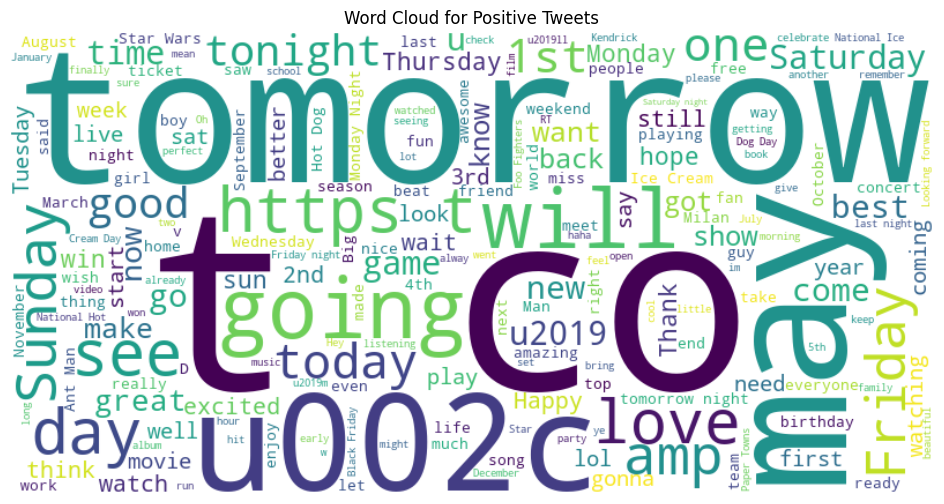

In [ ]:
from wordcloud import WordCloud

# Define the polarities and their labels
polarities = {-1: "Negative", 0: "Neutral", 1: "Positive"}

for polarity, label in polarities.items():
    # Filter the tweets for the given polarity
    text = " ".join(df_train[df_train['Polarity'] == polarity]['Tweet'].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for {label} Tweets")
    plt.axis("off")
    plt.show()


Top 20 Most Common Hashtags:
[('RAW', 148), ('SummerSlam', 88), ('MTVStars', 84), ('trndnl', 84), ('WWE', 81), ('1', 75), ('BlueJays', 59), ('USOpen', 57), ('Cubs', 53), ('MLB', 49), ('Mets', 49), ('NFL', 46), ('news', 44), ('TheOpen', 43), ('News', 39), ('BB17', 36), ('Raw', 36), ('Brewers', 36), ('tcot', 33), ('VMAs', 32)]


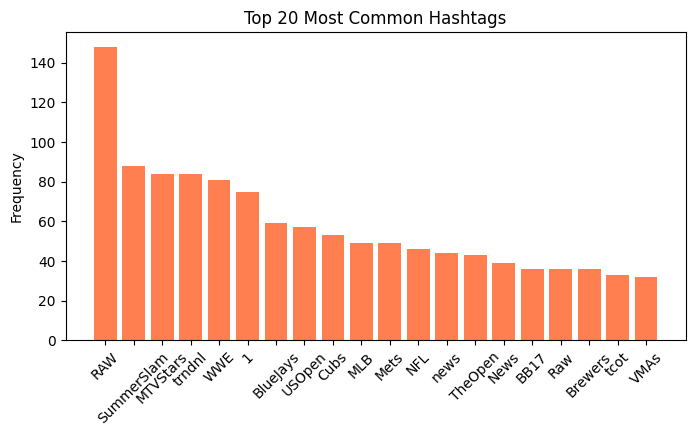

In [8]:
# Step 6: Extract and plot the most common hashtags

def extract_hashtags(text):
    return re.findall(r'#(\w+)', text)

hashtags = []
for tweet in df_train['Tweet']:
    hashtags.extend(extract_hashtags(tweet))

hashtag_freq = Counter(hashtags)
common_hashtags = hashtag_freq.most_common(20)
print("Top 20 Most Common Hashtags:")
print(common_hashtags)

# Plot hashtags
ht_words, ht_counts = zip(*common_hashtags)
plt.figure(figsize=(8, 4))
plt.bar(ht_words, ht_counts, color='coral')
plt.title("Top 20 Most Common Hashtags")
plt.xticks(rotation=45)
plt.ylabel("Frequency")
plt.show()


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # Remove URLs
    text = re.sub(r'@\w+', '', text)          # Remove mentions
    text = re.sub(r'#', '', text)             # Remove '#' symbol but keep the word
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub(r'\d+', '', text)           # Remove digits
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

# Apply preprocessing to both training and test tweets
df_train['processed_Tweet'] = df_train['Tweet'].apply(preprocess_text)
df_test['processed_Tweet'] = df_test['Tweet'].apply(preprocess_text)

print("Sample processed tweet:")
print(df_train['processed_Tweet'].head())


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\essol\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\essol\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\essol\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Sample processed tweet:
0    runway renovation airport prevent seeing taylo...
1    bad blood may absolute worst lyricism ive ever...
2    parent going zac brown band concert tomorrow n...
3     growth gerontocracy george osborne assault young
4    hidden budget tax rise george osborne didnt wa...
Name: processed_Tweet, dtype: object


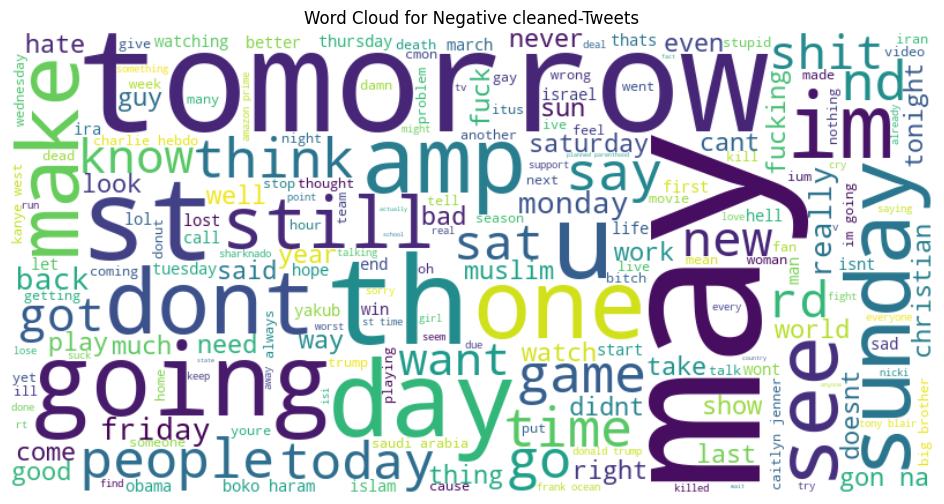

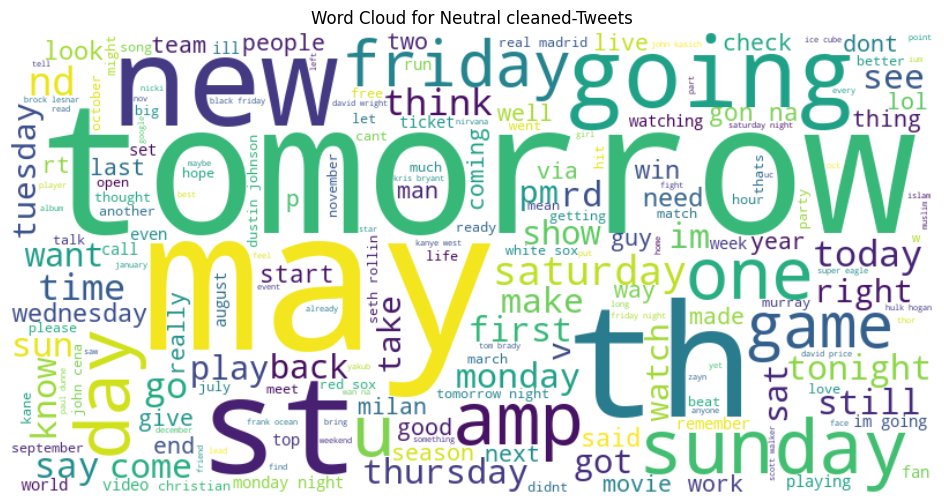

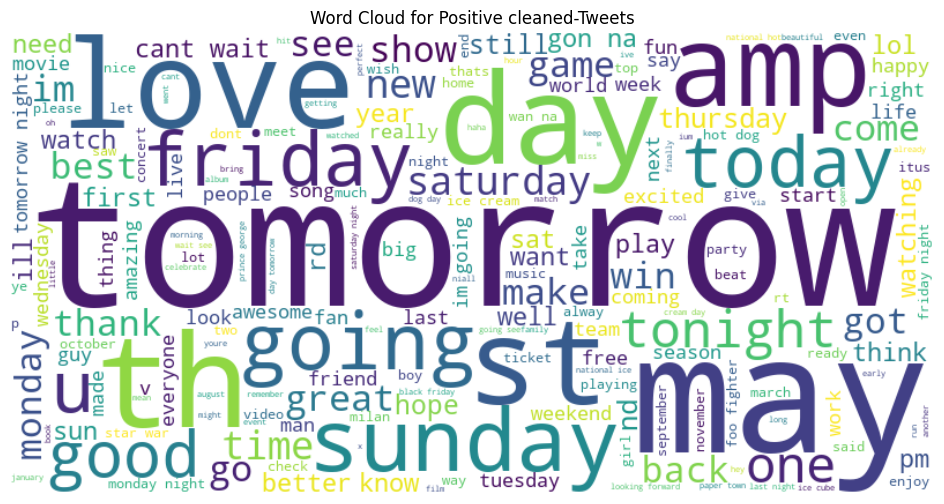

In [ ]:
# Define the polarities and their labels
polarities = {-1: "Negative", 0: "Neutral", 1: "Positive"}

for polarity, label in polarities.items():
    # Filter the tweets for the given polarity
    text = " ".join(df_train[df_train['Polarity'] == polarity]['processed_Tweet'].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for {label} cleaned-Tweets")
    plt.axis("off")
    plt.show()


In [10]:
# Step 8: TF-IDF Vectorization and Delta TF-IDF Calculation

from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize using TF-IDF with a maximum of 10,000 features
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(df_train['processed_Tweet'])
X_test_tfidf = vectorizer.transform(df_test['processed_Tweet'])

# Save sentiment labels
y_train = df_train['Polarity']
y_test = df_test['Polarity']

# Compute Delta TF-IDF: Difference between positive and negative tweets
pos_indices = df_train['Polarity'] == 1
neg_indices = df_train['Polarity'] == -1

X_train_pos = vectorizer.transform(df_train.loc[pos_indices, 'processed_Tweet'])
X_train_neg = vectorizer.transform(df_train.loc[neg_indices, 'processed_Tweet'])

# Compute average TF-IDF for positive and negative classes
pos_mean = np.array(X_train_pos.mean(axis=0)).flatten()
neg_mean = np.array(X_train_neg.mean(axis=0)).flatten()

delta_tfidf = pos_mean - neg_mean

# Visualize the delta TF-IDF for words
features = vectorizer.get_feature_names_out()
delta_df = pd.DataFrame({'word': features, 'delta_tfidf': delta_tfidf})

print("Top 10 words indicative of positive sentiment:")
print(delta_df.sort_values(by='delta_tfidf', ascending=False).head(10))
print("\nTop 10 words indicative of negative sentiment:")
print(delta_df.sort_values(by='delta_tfidf', ascending=True).head(10))


Top 10 words indicative of positive sentiment:
          word  delta_tfidf
5234      love     0.010982
8984  tomorrow     0.010378
2231       day     0.010198
3898     happy     0.010028
3693      good     0.009636
7773       see     0.009339
858       best     0.009148
5972     night     0.007714
3764     great     0.007244
3010   excited     0.006440

Top 10 words indicative of negative sentiment:
        word  delta_tfidf
5435     may    -0.011726
2575    dont    -0.008108
7929    shit    -0.006616
3481    fuck    -0.006318
5806  muslim    -0.006283
5096    like    -0.005597
6473  people    -0.004912
9810   worst    -0.004879
3931    hate    -0.004870
7614     sad    -0.004343


In [11]:
# Step 9: Train and Evaluate Naïve Bayes

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naïve Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))
print("Naïve Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))


Naïve Bayes Classification Report:
              precision    recall  f1-score   support

          -1       0.73      0.27      0.40      3972
           0       0.57      0.76      0.65      5937
           1       0.48      0.57      0.52      2375

    accuracy                           0.57     12284
   macro avg       0.59      0.53      0.52     12284
weighted avg       0.60      0.57      0.54     12284

Naïve Bayes Accuracy: 0.565939433409313


In [12]:
# Step 10: Train and Evaluate Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

          -1       0.68      0.40      0.51      3972
           0       0.59      0.74      0.66      5937
           1       0.52      0.56      0.54      2375

    accuracy                           0.59     12284
   macro avg       0.60      0.57      0.57     12284
weighted avg       0.61      0.59      0.59     12284

Logistic Regression Accuracy: 0.5942689677629437


In [13]:
# Step 11: Prepare Data for the RNN and Build the LSTM Model

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Define parameters for tokenization and sequence padding
max_words = 10000  # Vocabulary size
max_len = 40       # Maximum tweet length (in words)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_train['processed_Tweet'])

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(df_train['processed_Tweet'])
X_test_seq = tokenizer.texts_to_sequences(df_test['processed_Tweet'])

# Pad sequences so that all have the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Map sentiment labels: -1 -> 0, 0 -> 1, 1 -> 2 (for categorical encoding)
label_map = {-1: 0, 0: 1, 1: 2}
y_train_cat = df_train['Polarity'].map(label_map).values
y_test_cat = df_test['Polarity'].map(label_map).values

# Convert labels to categorical format
y_train_cat = to_categorical(y_train_cat, num_classes=3)
y_test_cat = to_categorical(y_test_cat, num_classes=3)

# Build the LSTM-based RNN model
embedding_dim = 50

model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\essol\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Step 12: Train the RNN (LSTM) model
history = model.fit(X_train_pad, y_train_cat, epochs=30, batch_size=64, validation_split=0.1)


Epoch 1/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.4978 - loss: 1.0177 - val_accuracy: 0.0000e+00 - val_loss: 1.0983
Epoch 2/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4955 - loss: 1.0197 - val_accuracy: 0.0000e+00 - val_loss: 1.1007
Epoch 3/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.4996 - loss: 1.0155 - val_accuracy: 0.0000e+00 - val_loss: 1.1348
Epoch 4/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4966 - loss: 1.0188 - val_accuracy: 0.0000e+00 - val_loss: 1.1061
Epoch 5/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.4950 - loss: 1.0183 - val_accuracy: 0.0000e+00 - val_loss: 1.1492
Epoch 6/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5002 - loss: 1.0171 - val_accuracy: 0.0000e+00 - val_loss: 1.1056
Epoch 7/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4956 - loss: 1.0208 - val_accuracy: 0.0000e+00 - val_loss: 1.1175
Epoch 8/30
708/708 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accura

In [ ]:
# Step 13: Evaluate the RNN model

loss, accuracy = model.evaluate(X_test_pad, y_test_cat)
print("RNN Test Accuracy:", accuracy)

# Generate predictions and display a classification report

y_pred_rnn_prob = model.predict(X_test_pad)
y_pred_rnn = np.argmax(y_pred_rnn_prob, axis=1)
y_test_labels = np.argmax(y_test_cat, axis=1)

print("RNN Classification Report:")
print(classification_report(y_test_labels, y_pred_rnn, target_names=["negative", "neutral", "positive"]))


384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2927 - loss: 1.4315
RNN Test Accuracy: 0.48331162333488464
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RNN Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      3972
     neutral       0.48      1.00      0.65      5937
    positive       0.00      0.00      0.00      2375

    accuracy                           0.48     12284
   macro avg       0.16      0.33      0.22     12284
weighted avg       0.23      0.48      0.31     12284



C:\Users\essol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\essol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\essol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Naïve Bayes Performance:
              precision    recall  f1-score   support

          -1       0.73      0.27      0.40      3972
           0       0.57      0.76      0.65      5937
           1       0.48      0.57      0.52      2375

    accuracy                           0.57     12284
   macro avg       0.59      0.53      0.52     12284
weighted avg       0.60      0.57      0.54     12284



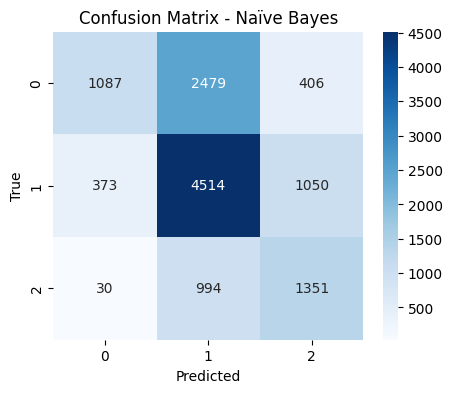

Logistic Regression Performance:
              precision    recall  f1-score   support

          -1       0.68      0.40      0.51      3972
           0       0.59      0.74      0.66      5937
           1       0.52      0.56      0.54      2375

    accuracy                           0.59     12284
   macro avg       0.60      0.57      0.57     12284
weighted avg       0.61      0.59      0.59     12284



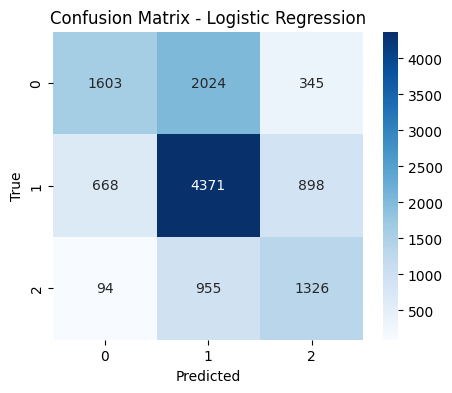

RNN Performance:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      3972
     neutral       0.48      1.00      0.65      5937
    positive       0.00      0.00      0.00      2375

    accuracy                           0.48     12284
   macro avg       0.16      0.33      0.22     12284
weighted avg       0.23      0.48      0.31     12284



C:\Users\essol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\essol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\essol\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

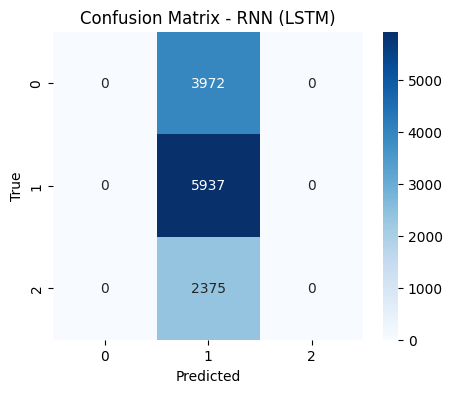

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Define a function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# For Naïve Bayes
print("Naïve Bayes Performance:")
print(classification_report(y_test, y_pred_nb))
plot_confusion_matrix(y_test, y_pred_nb, "Naïve Bayes")

# For Logistic Regression
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

# For RNN, we already have y_test_labels and y_pred_rnn
print("RNN Performance:")
print(classification_report(y_test_labels, y_pred_rnn, target_names=["negative", "neutral", "positive"]))
plot_confusion_matrix(y_test_labels, y_pred_rnn, "RNN (LSTM)")


In [98]:
def predict_sentiment_tfidf(tweet, model, vectorizer):
    # Preprocess tweet
    processed = preprocess_text(tweet)
    X = vectorizer.transform([processed])
    prediction = model.predict(X)
    return prediction[0]

# Sample tweet to test
sample_tweet = "my kid yesterday made me cry."
print("TF-IDF based prediction (Naïve Bayes):", predict_sentiment_tfidf(sample_tweet, nb_model, vectorizer))
print("TF-IDF based prediction (Logistic Regression):", predict_sentiment_tfidf(sample_tweet, lr_model, vectorizer))


TF-IDF based prediction (Naïve Bayes): 1
TF-IDF based prediction (Logistic Regression): -1


In [91]:
def predict_sentiment_rnn(tweet, tokenizer, model, max_len=40):
    processed = preprocess_text(tweet)
    seq = tokenizer.texts_to_sequences([processed])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    pred_prob = model.predict(padded)
    pred_class = np.argmax(pred_prob, axis=1)[0]
    # Reverse mapping: 0->negative, 1->neutral, 2->positive
    mapping = {0: "negative", 1: "neutral", 2: "positive"}
    return mapping[pred_class]

print("RNN prediction:", predict_sentiment_rnn(sample_tweet, tokenizer, model))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
RNN prediction: neutral


In [ ]:
#  Train and Evaluate SVM (LinearSVC)

from sklearn.svm import LinearSVC
# Initialize and train the SVM model using LinearSVC
svm_model = LinearSVC(max_iter=10000)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

# Print performance metrics for SVM
print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Classification Report:
              precision    recall  f1-score   support

          -1       0.63      0.46      0.53      3972
           0       0.60      0.65      0.62      5937
           1       0.46      0.58      0.51      2375

    accuracy                           0.57     12284
   macro avg       0.56      0.56      0.55     12284
weighted avg       0.58      0.57      0.57     12284

SVM Accuracy: 0.5725333767502442


In [99]:
print("TF-IDF based prediction (SVM):", predict_sentiment_tfidf(sample_tweet, svm_model, vectorizer))

TF-IDF based prediction (SVM): -1
